In [1]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt


In [2]:
file = uproot.open("/ceph/omunkombwe/fit_idea_o1_v03_new.root")
tree = file["events"]


In [3]:
mc_px = tree["MCParticles.momentum.x"].array()
mc_py = tree["MCParticles.momentum.y"].array()
mc_pz = tree["MCParticles.momentum.z"].array()

mc_pt = np.sqrt(mc_px ** 2 + mc_py ** 2)
mc_p = np.sqrt(mc_px ** 2 + mc_py ** 2 + mc_pz ** 2)
mc_status = tree["MCParticles.generatorStatus"].array()
mc_pdg = tree["MCParticles.PDG"].array()

subdetector_links = [
    ("DCH", tree["_DCHCollection_particle/_DCHCollection_particle.index"].array()),
    ("VTXB", tree["_VertexBarrelCollection_particle/_VertexBarrelCollection_particle.index"].array()),
    ("VTXE", tree["_VertexEndcapCollection_particle/_VertexEndcapCollection_particle.index"].array()),
    ("SiWrB", tree["_SiWrBCollection_particle/_SiWrBCollection_particle.index"].array()),
    ("SiWrD", tree["_SiWrDCollection_particle/_SiWrDCollection_particle.index"].array()),
]


In [4]:
TRACK_STATE_LOCATION = {
    "AtIP": 0,
    "AtFirstHit": 1,
    "AtLastHit": 2,
    "AtCalorimeter": 3,
    "AlongTrack": 4,
}

PT_COEFF = 0.000299792458  # GeV per (T*mm^-1); omega stored in mm^-1
B_FIELD_TESLA = 2.0  # Adjust if the fit used a different solenoid field

muon_track_starts = tree["Fitted_tracks_muon.trackStates_begin"].array()
muon_track_ends = tree["Fitted_tracks_muon.trackStates_end"].array()
muon_state_location = tree["_Fitted_tracks_muon_trackStates.location"].array()
muon_state_omega = tree["_Fitted_tracks_muon_trackStates.omega"].array()


In [5]:
def first_finite(values):
    for val in values:
        if np.isfinite(val):
            return float(val)
    return np.nan

muon_reco_pt_per_event = []
for begins_evt, ends_evt, omega_evt, loc_evt in zip(
    muon_track_starts,
    muon_track_ends,
    muon_state_omega,
    muon_state_location,
):
    begins_np = np.asarray(begins_evt, dtype=np.int64)
    ends_np = np.asarray(ends_evt, dtype=np.int64)
    omega_np = np.asarray(omega_evt, dtype=np.float64)
    loc_np = np.asarray(loc_evt, dtype=np.int16)

    per_event_pts = []
    for start, stop in zip(begins_np, ends_np):
        omega_slice = omega_np[start:stop]
        loc_slice = loc_np[start:stop]

        mask_first_hit = loc_slice == TRACK_STATE_LOCATION["AtFirstHit"]
        if mask_first_hit.any():
            omega_val = first_finite(omega_slice[mask_first_hit])
        else:
            omega_val = first_finite(omega_slice)

        if np.isfinite(omega_val) and omega_val != 0.0:
            per_event_pts.append((PT_COEFF * B_FIELD_TESLA) / abs(omega_val))

    muon_reco_pt_per_event.append(np.asarray(per_event_pts, dtype=np.float64))

muon_reco_pt = ak.Array(muon_reco_pt_per_event)
muon_reco_pt_flat = ak.to_numpy(ak.flatten(muon_reco_pt))


In [6]:
muon_truth_pt_per_event = []
for pt_evt, pdg_evt, status_evt in zip(mc_pt, mc_pdg, mc_status):
    pt_np = np.asarray(pt_evt)
    pdg_np = np.asarray(pdg_evt)
    status_np = np.asarray(status_evt)

    mask_muon = (np.abs(pdg_np) == 13) & (status_np == 1)
    muon_truth_pt_per_event.append(pt_np[mask_muon])

muon_truth_pt = ak.Array(muon_truth_pt_per_event)
muon_truth_pt_flat = ak.to_numpy(ak.flatten(muon_truth_pt))

matched_truth_pt = []
matched_reco_pt = []
for truth_evt, reco_evt in zip(muon_truth_pt_per_event, muon_reco_pt_per_event):
    if truth_evt.size == 0 or reco_evt.size == 0:
        continue

    truth_sorted = np.sort(truth_evt)[::-1]
    reco_sorted = np.sort(reco_evt)[::-1]
    match_count = min(truth_sorted.size, reco_sorted.size)
    if match_count == 0:
        continue

    matched_truth_pt.extend(truth_sorted[:match_count])
    matched_reco_pt.extend(reco_sorted[:match_count])

matched_truth_pt = np.asarray(matched_truth_pt)
matched_reco_pt = np.asarray(matched_reco_pt)

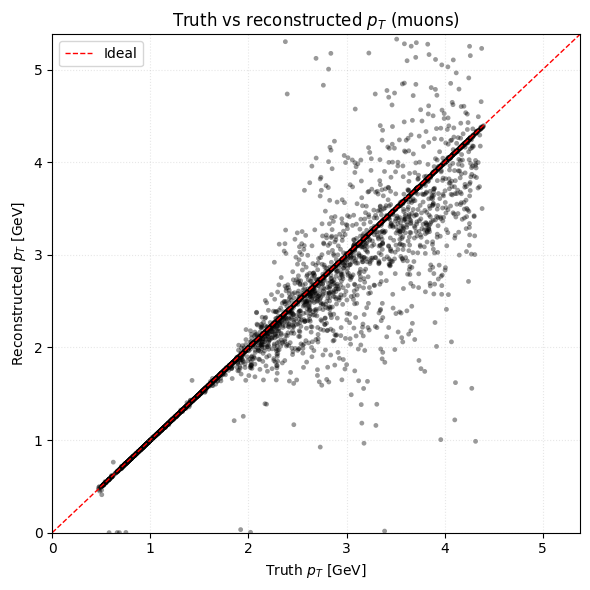

In [7]:
plt.figure(figsize=(6, 6))
if matched_truth_pt.size and matched_reco_pt.size:
    pt_max_plot = np.percentile(np.concatenate([matched_truth_pt, matched_reco_pt]), 99)
    pt_max_plot = max(1.0, float(pt_max_plot) * 1.1)
else:
    pt_max_plot = 1.0

plt.scatter(matched_truth_pt, matched_reco_pt, s=12, alpha=0.4, edgecolor="none", color="black")
plt.plot([0.0, pt_max_plot], [0.0, pt_max_plot], linestyle="--", color="red", linewidth=1.0, label="Ideal")
plt.xlim(0.0, pt_max_plot)
plt.ylim(0.0, pt_max_plot)
plt.xlabel(r"Truth $p_{T}$ [GeV]")
plt.ylabel(r"Reconstructed $p_{T}$ [GeV]")
plt.title(r"Truth vs reconstructed $p_{T}$ (muons)")
plt.grid(True, linestyle=":", alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig("pt_truth_vs_pt_reco_scatter.png", dpi=300)
plt.show()


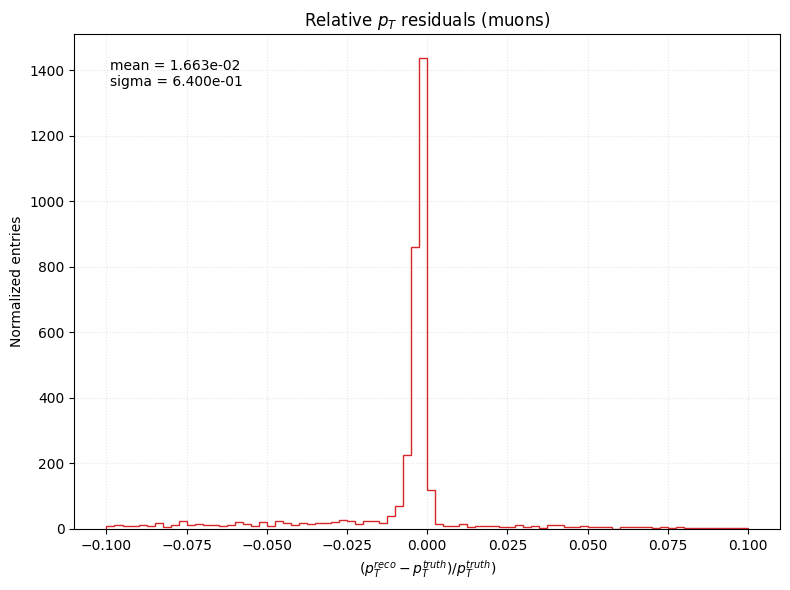

In [8]:
plt.figure(figsize=(8, 6))
valid_truth = matched_truth_pt != 0.0
resolution = np.zeros_like(matched_truth_pt)
if valid_truth.any():
    resolution[valid_truth] = (matched_reco_pt[valid_truth] - matched_truth_pt[valid_truth]) / matched_truth_pt[valid_truth] 
    plt.hist(resolution[valid_truth], bins=80, range=(-0.1, 0.1), histtype="step", color="tab:red")
    mean_res = float(np.mean(resolution[valid_truth]))
    sigma_res = float(np.std(resolution[valid_truth]))
    plt.text(0.05, 0.95, f"mean = {mean_res:.3e}\nsigma = {sigma_res:.3e}", transform=plt.gca().transAxes, verticalalignment="top")
else:
    plt.hist([], bins=80, range=(-0.2, 0.2), histtype="step", color="tab:red")
plt.xlabel(r"($p_{T}^{reco} - p_{T}^{truth}) / p_{T}^{truth}$)")
plt.ylabel("Normalized entries")
plt.title(r"Relative $p_{T}$ residuals (muons)")
plt.grid(True, linestyle=":", alpha=0.3)
plt.tight_layout()
plt.savefig("pt_resolution_muons.png", dpi=300)
plt.show()


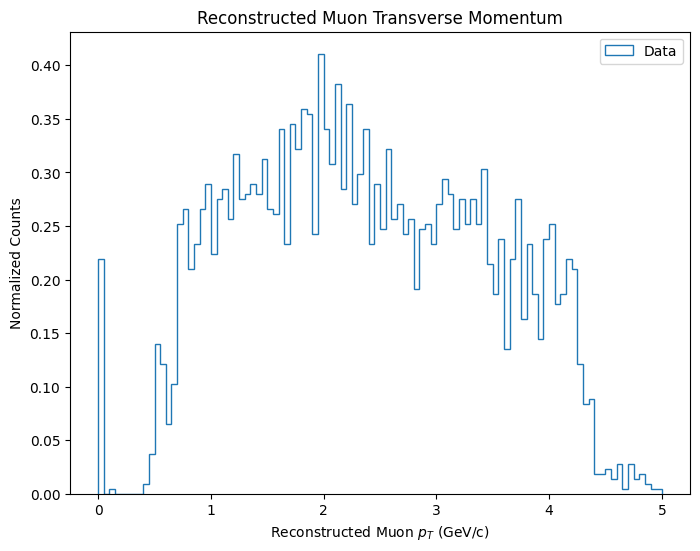

In [9]:
plt.figure(figsize=(8, 6))
plt.hist(muon_reco_pt_flat, bins=100, range=(0, 5), histtype="step", density=True)
plt.xlabel("Reconstructed Muon $p_{T}$ (GeV/c)")
plt.ylabel("Normalized Counts")
plt.title("Reconstructed Muon Transverse Momentum")
plt.legend(["Data"])
plt.savefig("muon_reco_pt.png")
plt.show()

In [10]:
hit_counts_per_particle = []
for evt_idx in range(len(mc_px)):
    num_particles = len(mc_px[evt_idx])
    if num_particles == 0:
        hit_counts_per_particle.append(np.zeros(0))
        continue

    total_counts = np.zeros(num_particles)
    for _, idx_collection in subdetector_links:
        idx_evt = idx_collection[evt_idx]
        idx_np = np.asarray(idx_evt)
        if idx_np.size == 0:
            continue

        valid = idx_np[(idx_np >= 0) & (idx_np < num_particles)]
        if valid.size:
            total_counts += np.bincount(valid, minlength=num_particles)

    hit_counts_per_particle.append(total_counts)

hit_counts = ak.Array(hit_counts_per_particle)

primary_mask = mc_status == 1
mc_pt_primary = ak.to_numpy(ak.flatten(mc_pt[primary_mask]))
mc_p_primary = ak.to_numpy(ak.flatten(mc_p[primary_mask]))
hit_counts_primary = ak.to_numpy(ak.flatten(hit_counts[primary_mask]))

mc_pt_all = ak.to_numpy(ak.flatten(mc_pt))
hit_counts_all = ak.to_numpy(ak.flatten(hit_counts))

pt_max_truth = mc_pt_primary.max() if mc_pt_primary.size else 0.0
hits_max_truth = hit_counts_primary.max() if hit_counts_primary.size else 0.0
pt_range_truth = (0.0, max(1.0, pt_max_truth * 1.05))
hits_range_truth = (0.0, max(10.0, hits_max_truth * 1.10))


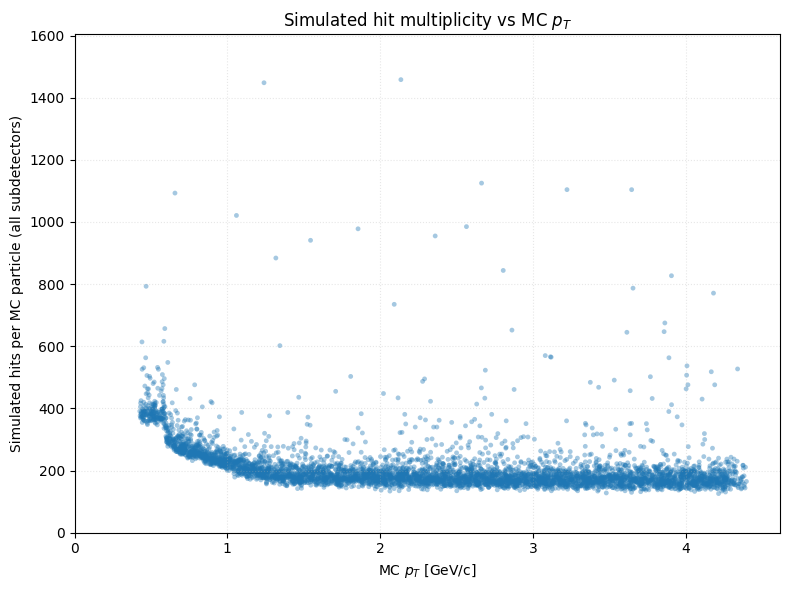

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(mc_pt_primary, hit_counts_primary, s=12, alpha=0.4, edgecolor="none", color="tab:blue")
plt.xlabel(r"MC $p_{T}$ [GeV/c]")
plt.ylabel("Simulated hits per MC particle (all subdetectors)")
plt.title("Simulated hit multiplicity vs MC $p_{T}$")
plt.xlim(*pt_range_truth)
plt.ylim(*hits_range_truth)
plt.grid(True, linestyle=":", alpha=0.3)
plt.tight_layout()
plt.savefig("mc_pt_vs_sim_hits_scatter_primary.png", dpi=300)
plt.show()


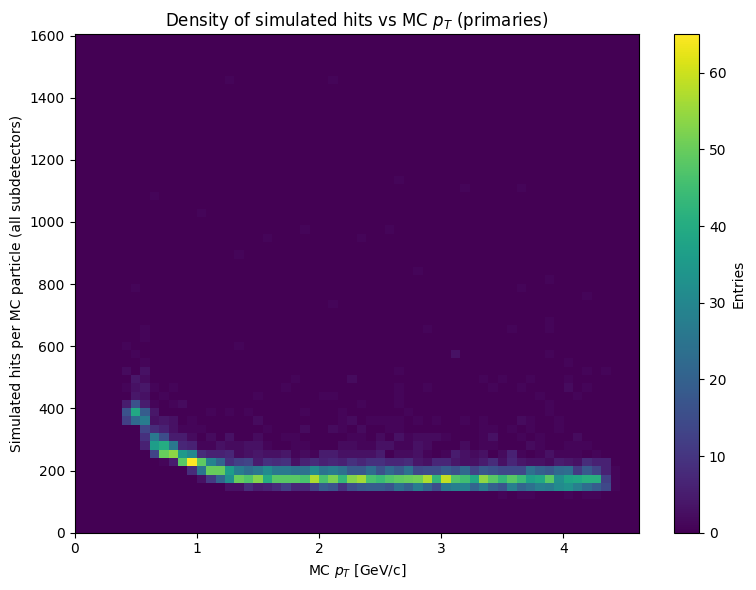

In [12]:
plt.figure(figsize=(8, 6))
plt.hist2d(
    mc_pt_primary,
    hit_counts_primary,
    bins=[60, 60],
    range=[pt_range_truth, hits_range_truth],
    cmap="viridis",
)
plt.colorbar(label="Entries")
plt.xlabel(r"MC $p_{T}$ [GeV/c]")
plt.ylabel("Simulated hits per MC particle (all subdetectors)")
plt.title("Density of simulated hits vs MC $p_{T}$ (primaries)")
plt.tight_layout()
plt.savefig("mc_pt_vs_sim_hits_hist2d_primary.png", dpi=300)
plt.show()


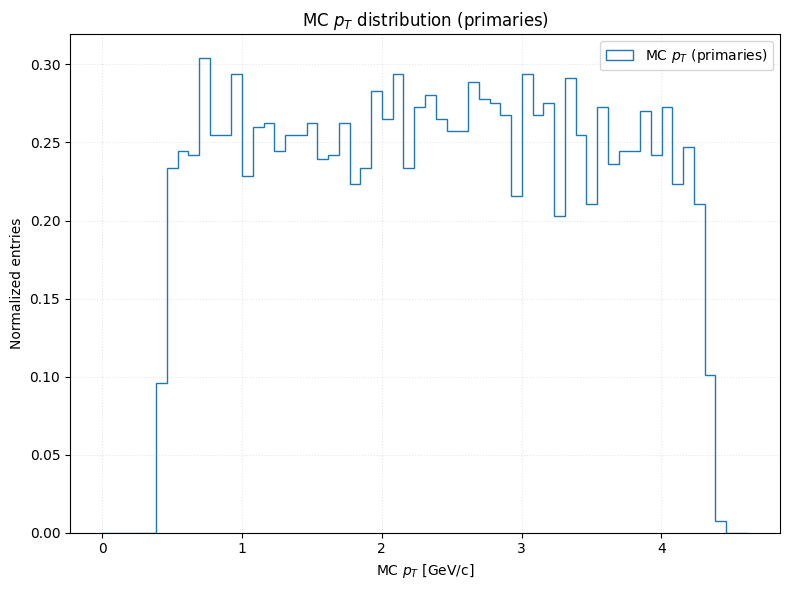

In [13]:
plt.figure(figsize=(8, 6))
plt.hist(
    mc_pt_primary,
    bins=60,
    range=pt_range_truth,
    histtype="step",
    density=True,
    color="tab:blue",
    label="MC $p_{T}$ (primaries)",
)
plt.xlabel(r"MC $p_{T}$ [GeV/c]")
plt.ylabel("Normalized entries")
plt.title(r"MC $p_{T}$ distribution (primaries)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.3)
plt.tight_layout()
#plt.savefig("mc_pt_normalized_distribution_primary.png", dpi=300)
plt.show()


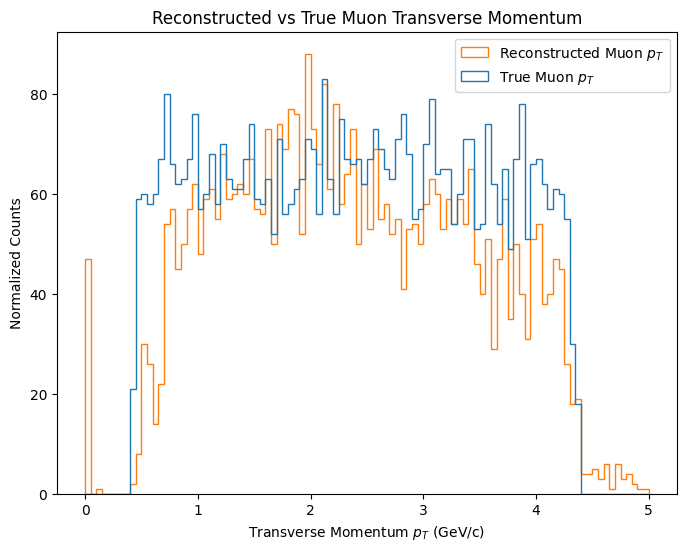

In [14]:
plt.figure(figsize=(8, 6))
plt.hist(muon_reco_pt_flat, bins=100, range=(0, 5), histtype="step",  color="tab:orange")
plt.hist(mc_pt_primary, bins=100, range=(0, 5), histtype="step")
plt.xlabel("Transverse Momentum $p_{T}$ (GeV/c)")
plt.ylabel("Normalized Counts")
plt.title("Reconstructed vs True Muon Transverse Momentum")
plt.legend(["Reconstructed Muon $p_{T}$", "True Muon $p_{T}$"])
#plt.savefig("muon_reco_vs_true_pt.png")
plt.show()

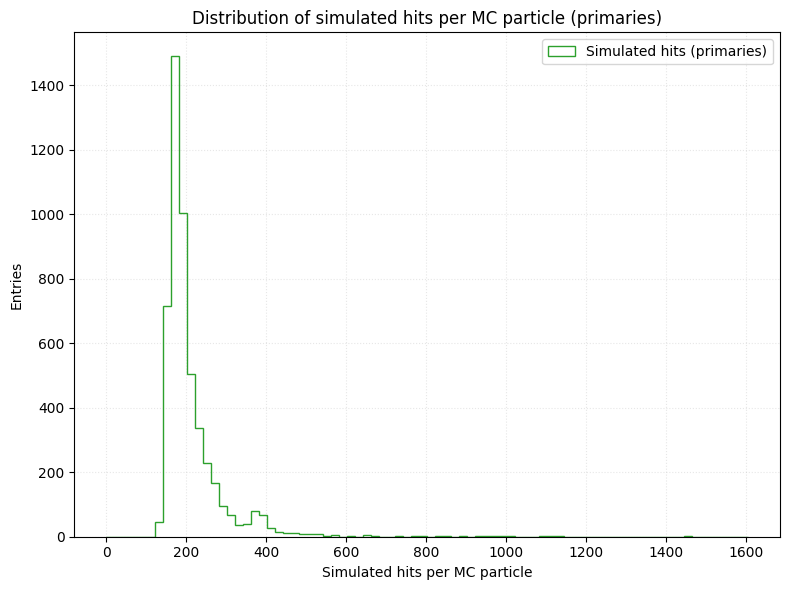

In [15]:
hits_hist_max = hits_range_truth[1]
plt.figure(figsize=(8, 6))
plt.hist(
    hit_counts_primary,
    bins=80,
    range=(0.0, hits_hist_max),
    histtype="step",
    color="tab:green",
    label="Simulated hits (primaries)",
)
plt.xlabel("Simulated hits per MC particle")
plt.ylabel("Entries")
plt.title("Distribution of simulated hits per MC particle (primaries)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.3)
plt.tight_layout()
plt.savefig("hit_counts_distribution_primary.png", dpi=300)
plt.show()
